FNN, CNN, GAN, VAE models on cifar -10 dataset

IMPORTS + LOAD DATASET

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print(x_train.shape, y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (50000, 1)


PREPROCESSING

In [3]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

MODEL 1: FNN (Fully Connected Neural Network)

In [4]:
# Flatten images
x_train_fnn = x_train.reshape(-1, 32*32*3)
x_test_fnn = x_test.reshape(-1, 32*32*3)

# Model
fnn_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

fnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

fnn_model.fit(x_train_fnn, y_train, epochs=10)

fnn_test_loss, fnn_test_acc = fnn_model.evaluate(x_test_fnn, y_test)
print("FNN Accuracy:", fnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.3312 - loss: 1.8586
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.4026 - loss: 1.6643
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.4325 - loss: 1.5884
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4534 - loss: 1.5331
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.4626 - loss: 1.5032
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.4719 - loss: 1.4706
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.4823 - loss: 1.4440
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.4907 - loss: 1.4256
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4967 - loss: 1.4080
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.5025 - loss: 1.3925
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4890 - loss: 1.4644
FNN Accuracy: 0.48899999

MODEL 2: CNN (BEST MODEL)

In [5]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.fit(x_train, y_train, epochs=10)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test)
print("CNN Accuracy:", cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4706 - loss: 1.4600
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.6174 - loss: 1.0903
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.6775 - loss: 0.9178
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.7192 - loss: 0.8016
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.7511 - loss: 0.7150
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7783 - loss: 0.6344
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.8005 - loss: 0.5714
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.8227 - loss: 0.5008
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.8465 - loss: 0.4344
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 49ms/step - accuracy: 0.8638 - loss: 0.3792
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7107 - loss: 1.0161
CNN Accuracy: 0.7106999

MODEL 3: GAN (IMAGE GENERATION)

In [6]:
# Generator
def build_generator():
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_dim=100),
        layers.Dense(512, activation='relu'),
        layers.Dense(1024, activation='relu'),
        layers.Dense(32*32*3, activation='tanh'),
        layers.Reshape((32,32,3))
    ])
    return model

# Discriminator
def build_discriminator():
    model = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# GAN combined
discriminator.trainable = False

gan_input = layers.Input(shape=(100,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan_model = models.Model(gan_input, gan_output)

gan_model.compile(optimizer='adam', loss='binary_crossentropy')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GAN TRAINING LOOP

In [7]:
epochs = 1000
batch_size = 64

for epoch in range(epochs):

    # Train Discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, 100))
    fake_imgs = generator.predict(noise)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    g_loss = gan_model.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss_real[0]} | G Loss: {g_loss}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.46513429284095764 | G Loss: 0.6811568737030029
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━

MODEL 4: VAE (AUTOENCODER STYLE)

In [8]:
latent_dim = 2

# Encoder
encoder_inputs = layers.Input(shape=(32,32,3))
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(256, activation='relu')(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

# Sampling
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

# Decoder
decoder_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation='relu')(decoder_inputs)
x = layers.Dense(32*32*3, activation='sigmoid')(x)
decoder_outputs = layers.Reshape((32,32,3))(x)

decoder = models.Model(decoder_inputs, decoder_outputs)
outputs = decoder(z)

vae = models.Model(encoder_inputs, outputs)

vae.compile(optimizer='adam', loss='mse')

vae.fit(x_train, x_train, epochs=10, batch_size=128)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - loss: 0.0434
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 0.0373
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 0.0370
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 0.0369
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.0368
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 0.0367
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - loss: 0.0366
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 0.0364
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - loss: 0.0364
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 0.0362


FINAL COMPARISON

In [9]:
print("FNN Accuracy:", fnn_test_acc)
print("CNN Accuracy:", cnn_test_acc)
print("GAN: Generates images (no accuracy)")
print("VAE: Reconstructs images (no accuracy)")

FNN Accuracy: 0.48899999260902405
CNN Accuracy: 0.7106999754905701
GAN: Generates images (no accuracy)
VAE: Reconstructs images (no accuracy)


CNN Prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


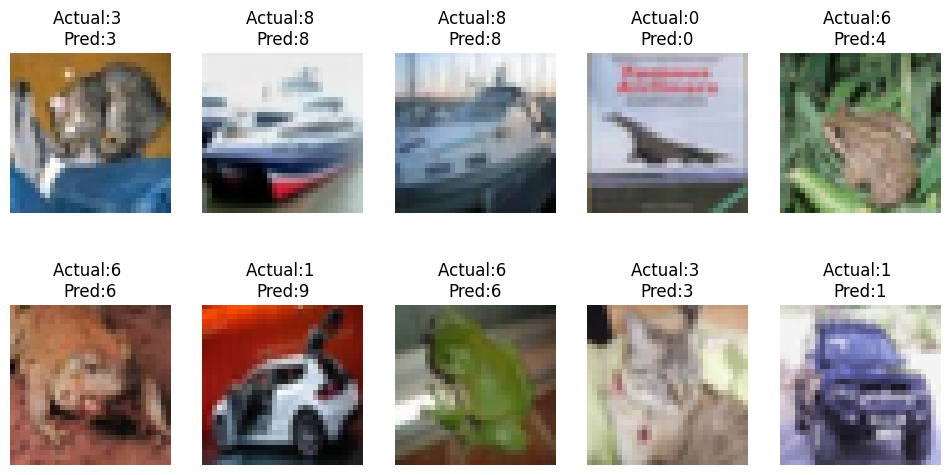

In [12]:
predictions = cnn_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    plt.title(f"Actual:{y_test[i]} \nPred:{predicted_labels[i]}")
    plt.axis('off')

plt.show()

FNN Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


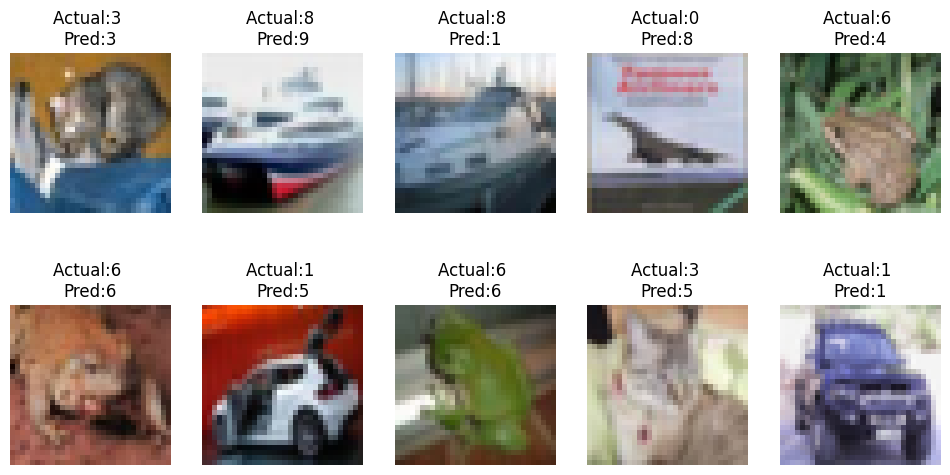

In [13]:
predictions = fnn_model.predict(x_test_fnn)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    img = x_test_fnn[i].reshape(32,32,3)
    plt.imshow(img)
    plt.title(f"Actual:{y_test[i]} \nPred:{predicted_labels[i]}")
    plt.axis('off')

plt.show()

GAN — TESTING

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


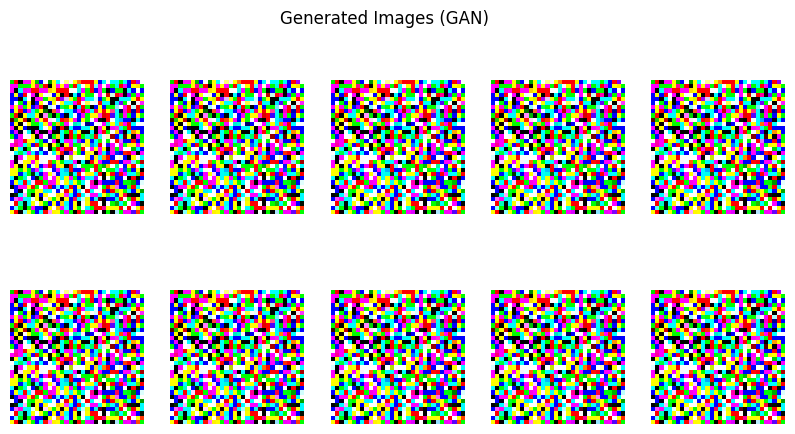

In [10]:
# Generate and display images
import matplotlib.pyplot as plt

num_images = 10
noise = np.random.normal(0, 1, (num_images, 100))

generated_images = generator.predict(noise)

plt.figure(figsize=(10,5))

for i in range(num_images):
    plt.subplot(2,5,i+1)

    # Convert from [-1,1] to [0,1] if using tanh
    img = (generated_images[i] + 1) / 2

    plt.imshow(img)
    plt.axis('off')

plt.suptitle("Generated Images (GAN)")
plt.show()

VAE — TESTING

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


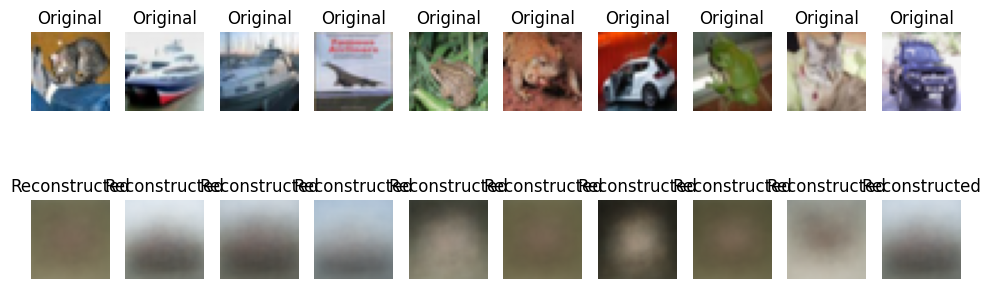

In [11]:
# Reconstruct images
reconstructed = vae.predict(x_test[:10])

plt.figure(figsize=(12,4))

for i in range(10):
    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(reconstructed[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()